### EDA

라이브러리 & 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# 한글 폰트 설정 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('house_raw.csv')
print(f"행: {df.shape[0]}, 열: {df.shape[1]}")
df.head()

행: 1460, 열: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


① 타겟 변수 분포 확인

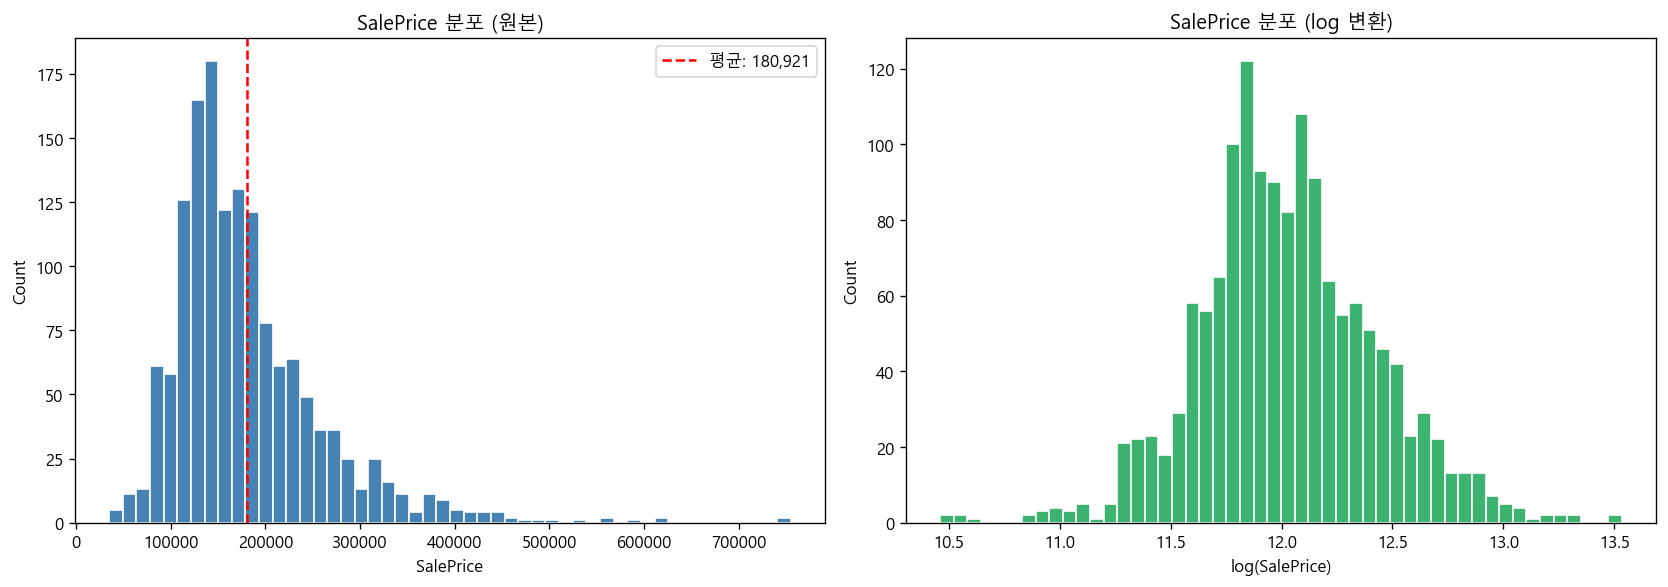

왜도 (원본): 1.8829
왜도 (log변환): 0.1213


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice 분포 (원본)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"평균: {df['SalePrice'].mean():,.0f}")
axes[0].legend()

# log 변환
log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('SalePrice 분포 (log 변환)')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_01_saleprice_dist.png', bbox_inches='tight')
plt.show()

print(f"왜도 (원본): {df['SalePrice'].skew():.4f}")
print(f"왜도 (log변환): {log_price.skew():.4f}")

② 결측치 현황

              결측 수  결측 비율(%)
PoolQC        1453     99.52
MiscFeature   1406     96.30
Alley         1369     93.77
Fence         1179     80.75
MasVnrType     872     59.73
FireplaceQu    690     47.26
LotFrontage    259     17.74
GarageType      81      5.55
GarageYrBlt     81      5.55
GarageFinish    81      5.55
GarageQual      81      5.55
GarageCond      81      5.55
BsmtExposure    38      2.60
BsmtFinType2    38      2.60
BsmtQual        37      2.53
BsmtCond        37      2.53
BsmtFinType1    37      2.53
MasVnrArea       8      0.55
Electrical       1      0.07


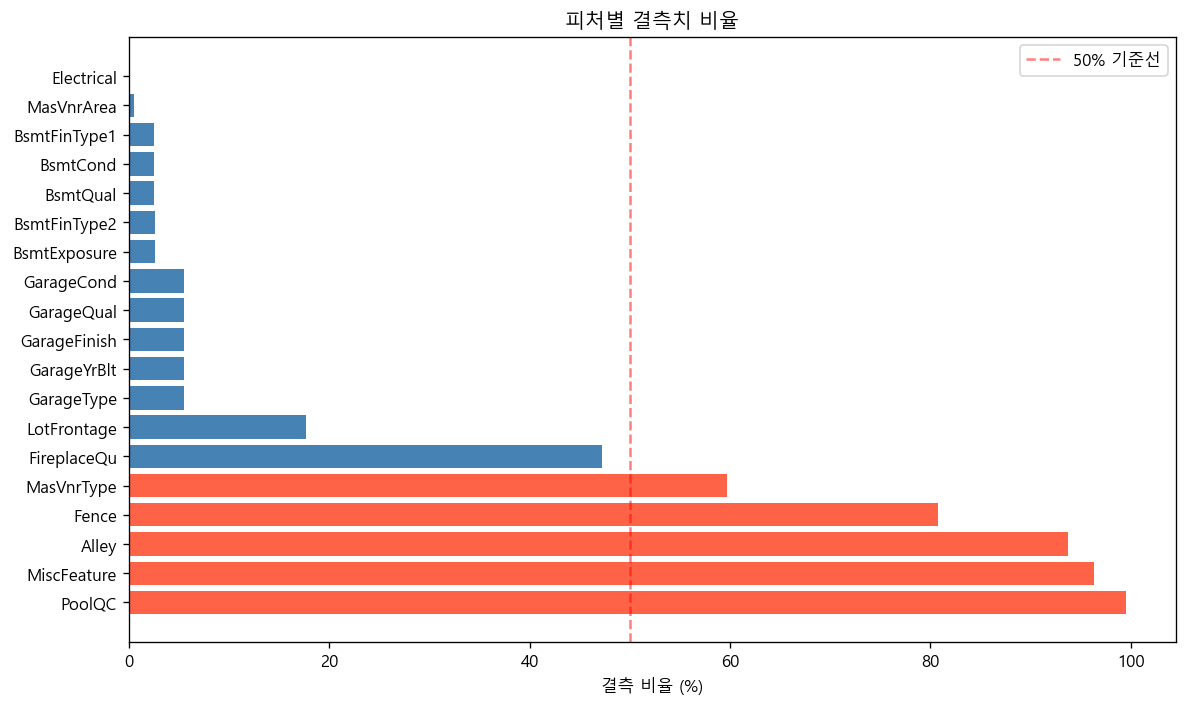

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if x > 50 else 'steelblue' for x in missing_pct]
ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.set_xlabel('결측 비율 (%)')
ax.set_title('피처별 결측치 비율')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
ax.legend()
plt.tight_layout()
plt.savefig('eda_02_missing.png', bbox_inches='tight')
plt.show()

③ 수치형 피처 상관관계 히트맵

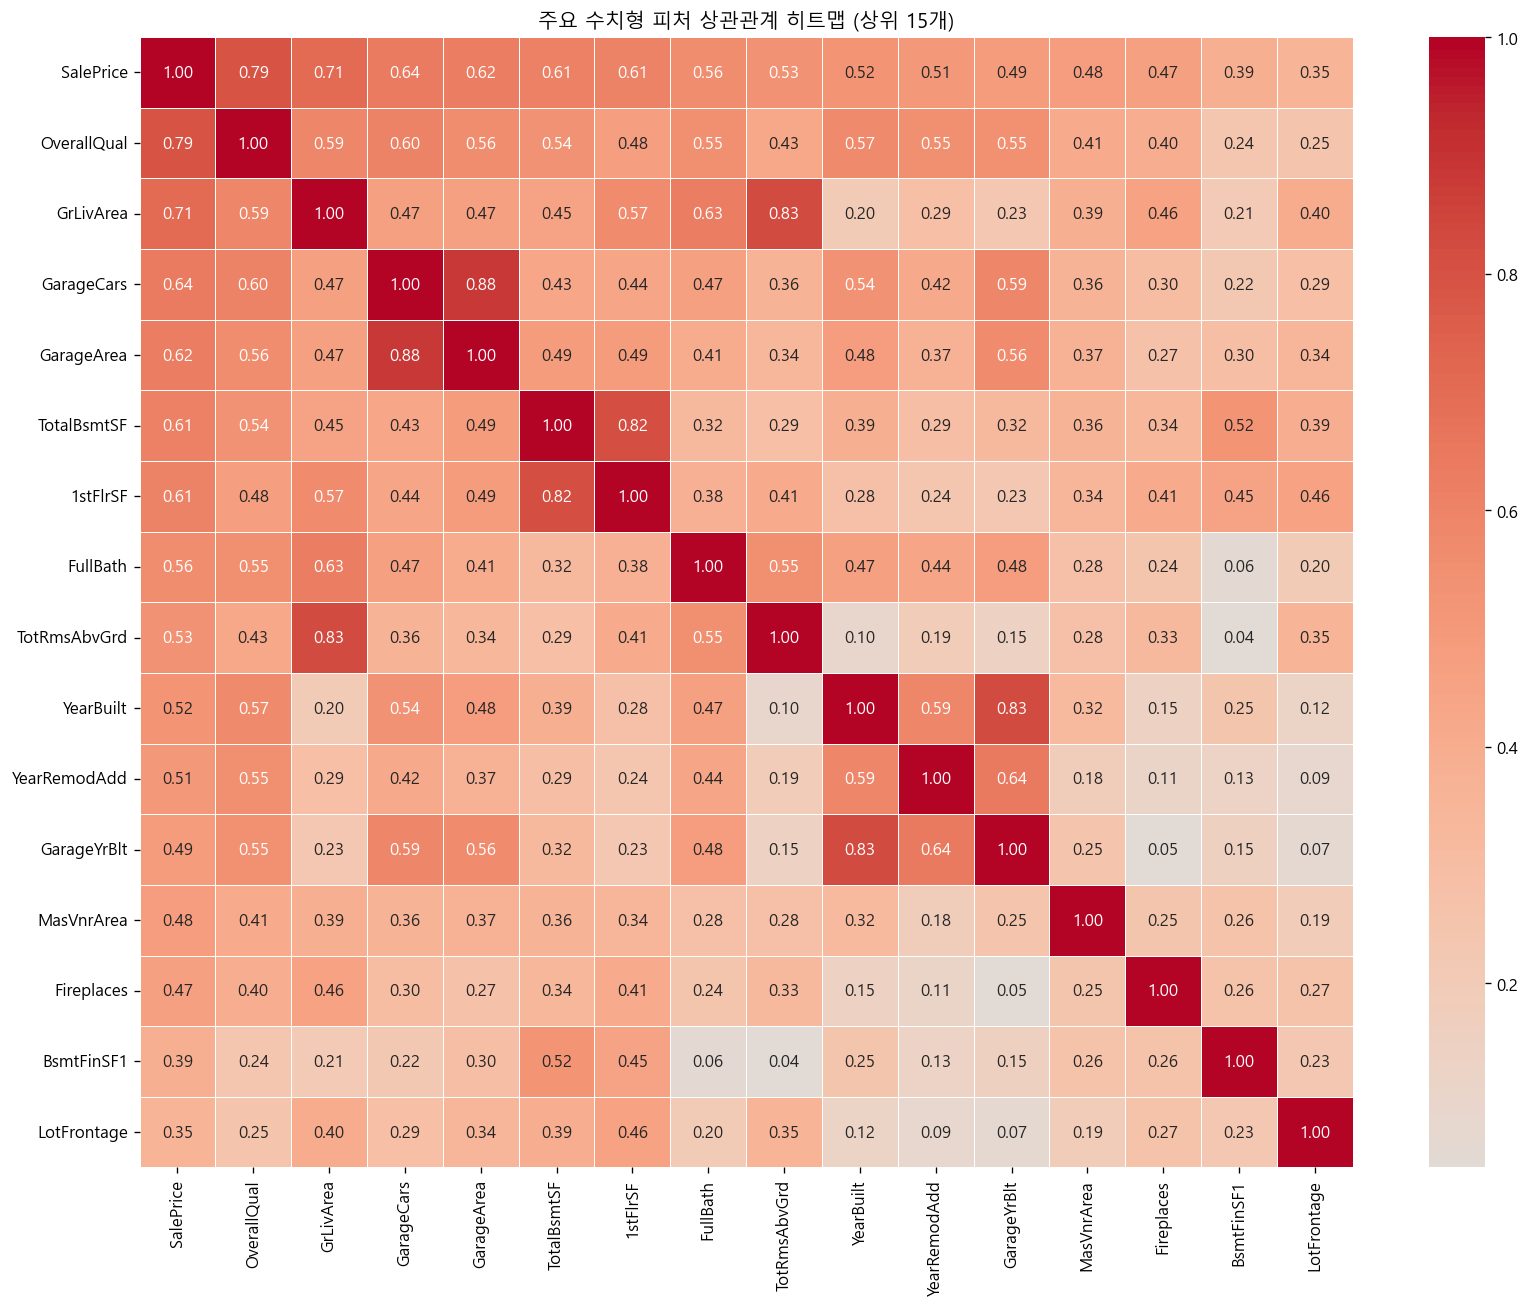


SalePrice와 상관관계 상위 10개:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [4]:
num_df = df.select_dtypes(include=[np.number])

# SalePrice와 상관관계 상위 15개 추출
corr_with_target = num_df.corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = corr_with_target.iloc[1:16].index.tolist()  # SalePrice 자기 자신 제외
top_features = ['SalePrice'] + top_features

corr_matrix = num_df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('주요 수치형 피처 상관관계 히트맵 (상위 15개)')
plt.tight_layout()
plt.savefig('eda_03_heatmap.png', bbox_inches='tight')
plt.show()

print("\nSalePrice와 상관관계 상위 10개:")
print(corr_with_target.head(11)) 

 ④ 주요 수치형 피처 vs SalePrice 산점도

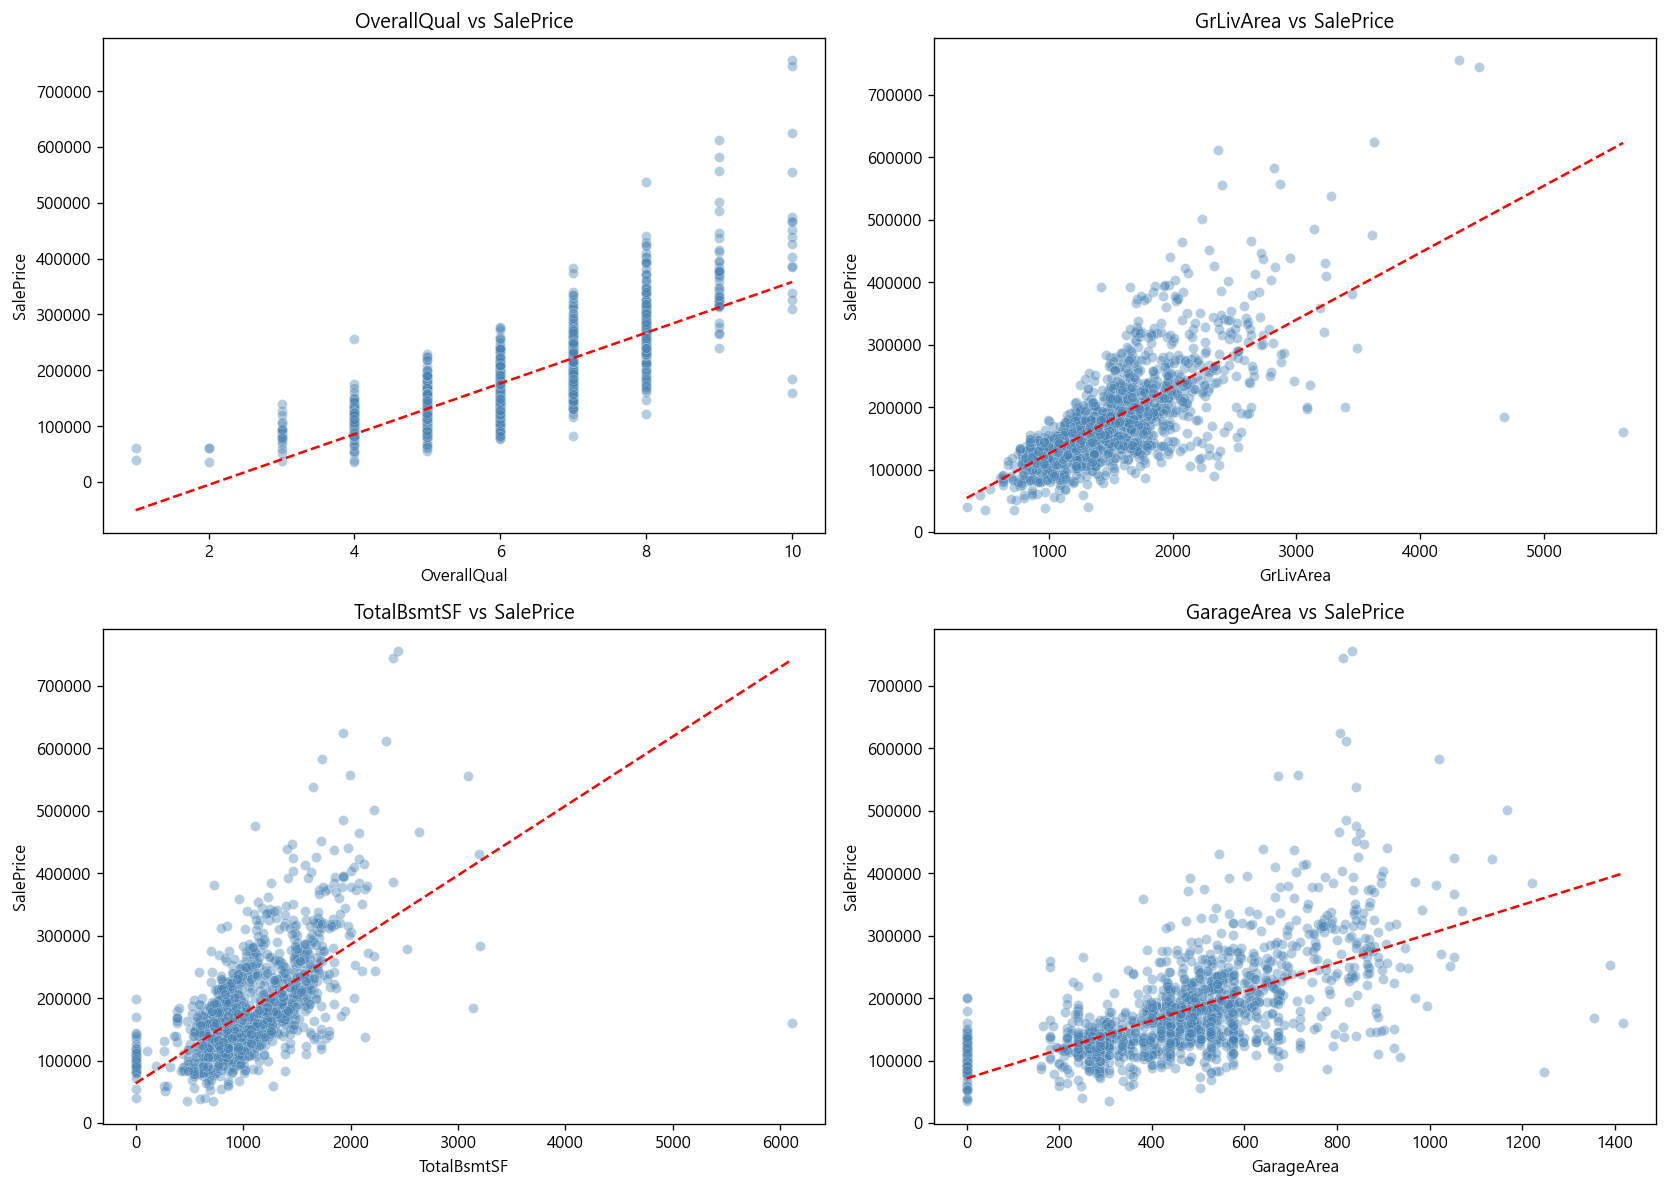

In [5]:
scatter_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(scatter_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

    # 추세선
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('eda_04_scatter.png', bbox_inches='tight')
plt.show()

 ⑤ 범주형 피처 박스플롯

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8904\2819212615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8904\2819212615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8904\2819212615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8904\2819212615.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

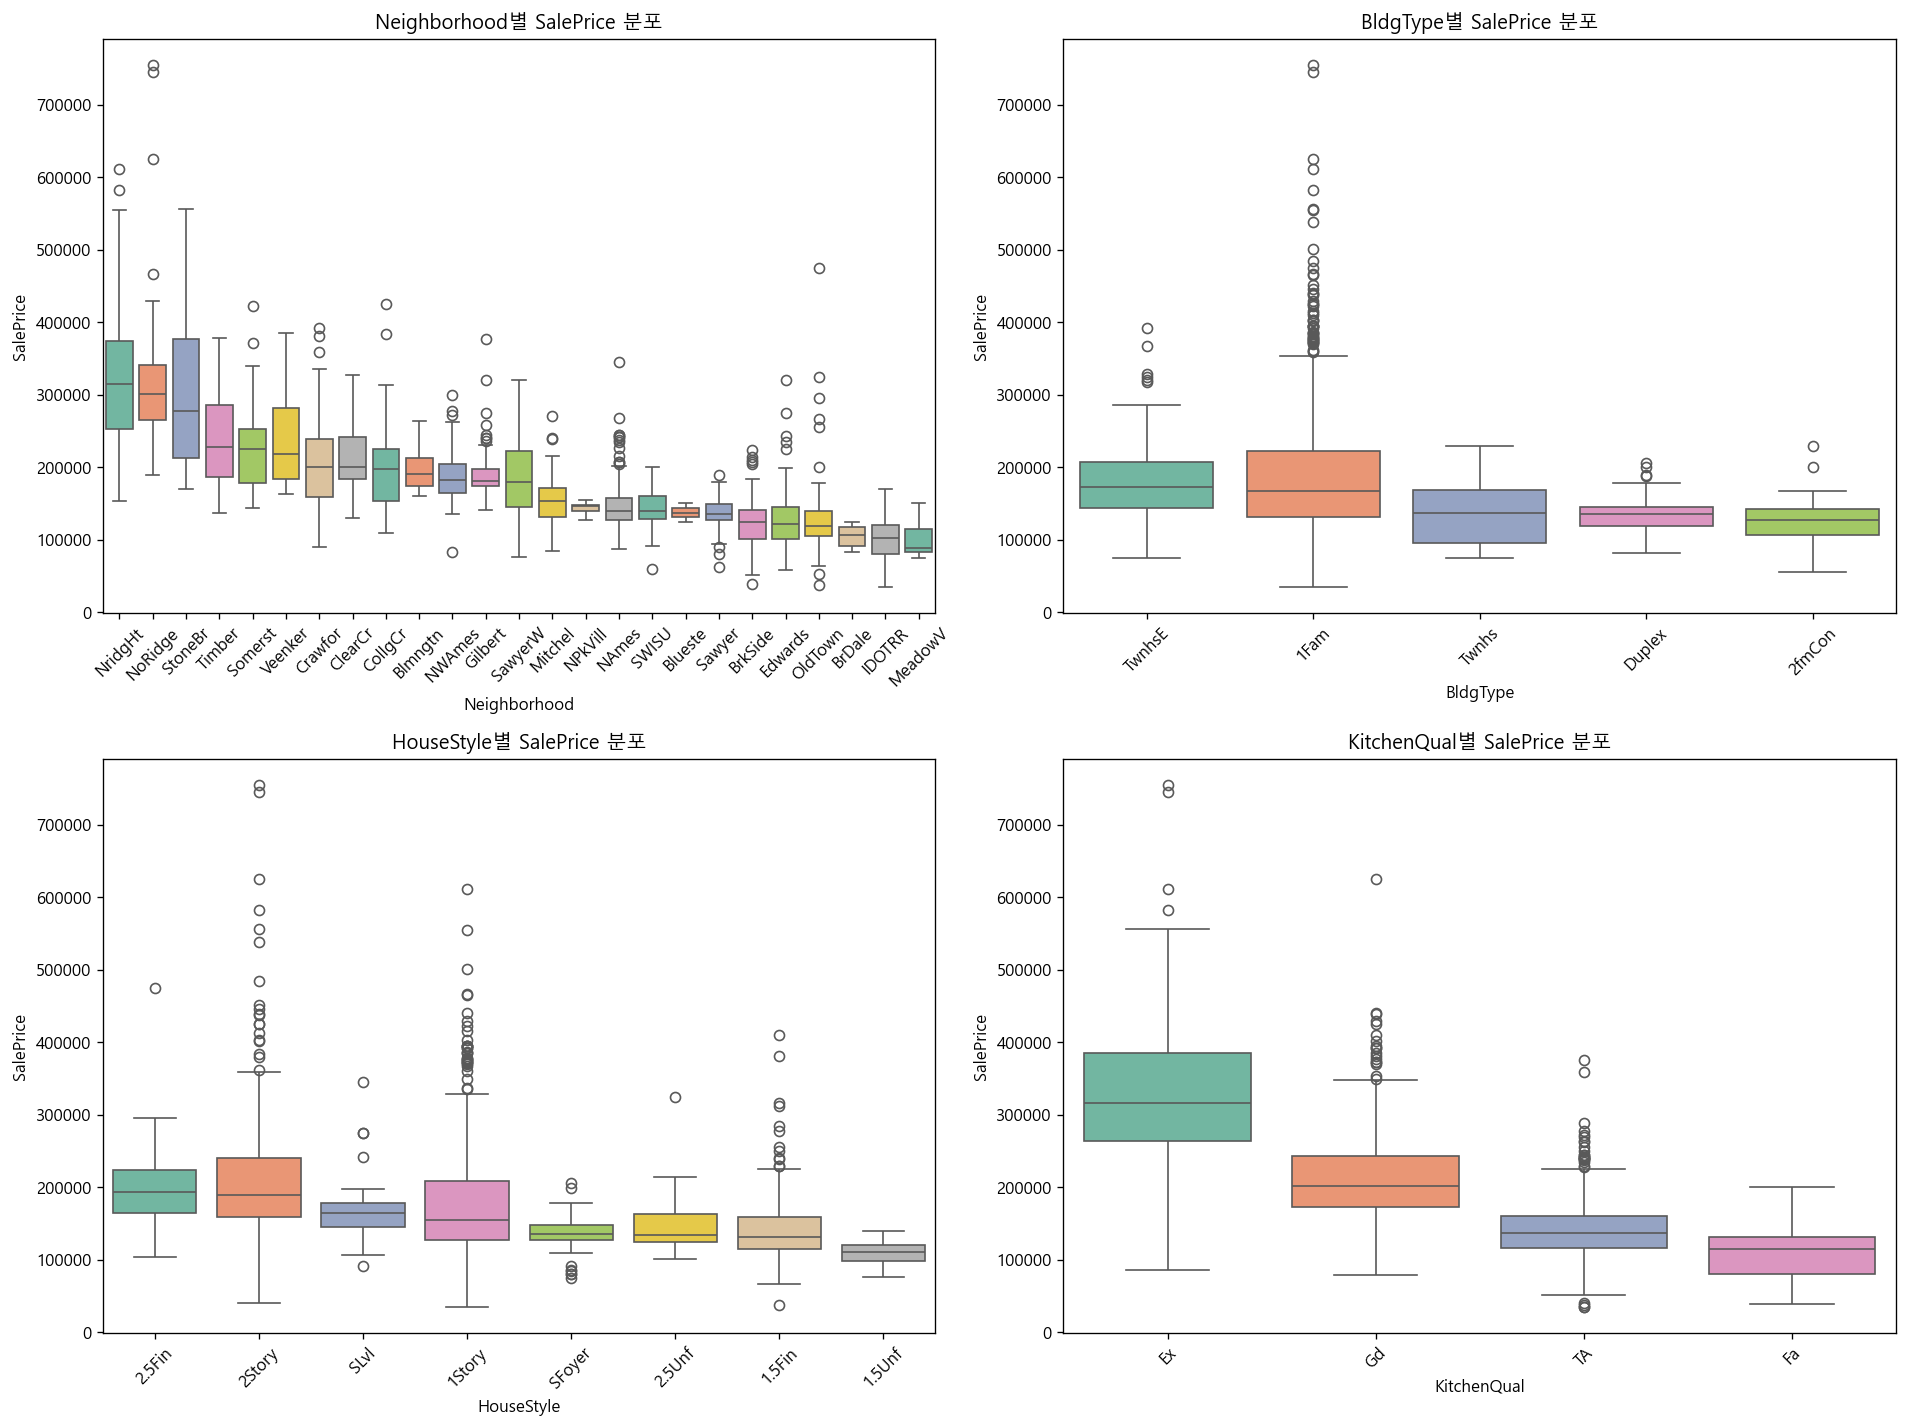

In [6]:
cat_features = ['Neighborhood', 'BldgType', 'HouseStyle', 'KitchenQual']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    order = df.groupby(feat)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=df, x=feat, y='SalePrice',
        order=order, ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f'{feat}별 SalePrice 분포')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_05_boxplot.png', bbox_inches='tight')
plt.show()

---

### EDA 결과 해석 및 전처리 전략

**① SalePrice 분포**
- 원본 왜도 심함 → log 변환 후 정규분포에 가까워짐
- **처리:** `np.log1p(SalePrice)` 적용 후 모델 학습, 예측 후 `np.expm1()`로 역변환 필요

---

**② 컬럼 드랍**

| 기준 | 피처 | 이유 |
|------|------|------|
| 결측 80% 이상 | `PoolQC`, `MiscFeature`, `Alley`, `Fence` | 정보보다 노이즈가 많음 |
| 중복 피처 | `GarageCars`, `1stFlrSF`, `TotRmsAbvGrd`, `GarageYrBlt` | 상관관계 0.82~0.88인 피처와 중복 |
| 분산 없음 | `Utilities`, `Street`, `Id` | 거의 단일값으로 모델 기여 없음 |

---

**③ 결측치 처리**

| 피처 | 결측 비율 | 해석 | 처리 방법 |
|------|----------|------|----------|
| `FireplaceQu` | 47% | 벽난로 없음 | `"None"`으로 대체 |
| `MasVnrType` | 59% | 외벽 마감재 없음 | `"None"`으로 대체 |
| `GarageType` 외 3개 | 5.5% | 차고 없는 집 | 문자형 → `"None"`, 수치형 → `0` |
| `BsmtQual` 외 4개 | 2.5% | 지하실 없는 집 | 문자형 → `"None"`, 수치형 → `0` |
| `LotFrontage` | 17% | 실제 누락값 | 같은 `Neighborhood` 내 중앙값으로 대체 |
| `Electrical` | 0.07% | 실제 누락값 | 최빈값으로 대체 |
| `MasVnrArea` | 0.55% | 마감재 없음 | `0`으로 대체 |

---

**④ 이상치 제거**
- `GrLivArea` 4000 이상이면서 가격이 낮은 데이터 2개 확인
- **처리:** 해당 2개 행 제거

---

**⑤ 인코딩**
- 품질 관련 피처 (`KitchenQual`, `ExterQual` 등) → Po/Fa/TA/Gd/Ex 순서 있음 → **Label Encoding (1~5)**
- 나머지 범주형 → **One-Hot Encoding**

---

**⑥ 다중공선성**
- `GarageCars`-`GarageArea`(0.88), `TotalBsmtSF`-`1stFlrSF`(0.82) 등 높은 상관관계 확인
- **처리:** 중복 피처 드랍으로 해결 (② 참고). 

### 전처리

 라이브러리 & 데이터 로드

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('house_raw.csv')
print(f"원본 행: {df.shape[0]}, 열: {df.shape[1]}")

원본 행: 1460, 열: 81


이상치 제거

In [8]:
# GrLivArea 크고 가격 낮은 이상치 2개 제거
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000))]
df = df.reset_index(drop=True)
print(f"이상치 제거 후 행 수: {len(df)}")

이상치 제거 후 행 수: 1458


타겟 변수 log 변환

In [9]:
df['SalePrice'] = np.log1p(df['SalePrice'])
print(f"SalePrice 왜도 (log 변환 후): {df['SalePrice'].skew():.4f}")

SalePrice 왜도 (log 변환 후): 0.1216


컬럼 드랍

In [10]:
drop_cols = [
    # 결측 80% 이상
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    # 중복 피처
    'GarageCars', '1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt',
    # 분산 없음 / 인덱스
    'Utilities', 'Street', 'Id'
]
df = df.drop(columns=drop_cols)
print(f"드랍 후 컬럼 수: {df.shape[1]}")

드랍 후 컬럼 수: 70


결측치 처리

In [11]:
# "없음"을 의미하는 문자형 결측치 → "None"
none_str_cols = [
    'FireplaceQu', 'MasVnrType',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for col in none_str_cols:
    df[col] = df[col].fillna('None')

# "없음"을 의미하는 수치형 결측치 → 0
none_num_cols = [
    'GarageArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]
for col in none_num_cols:
    df[col] = df[col].fillna(0)

# LotFrontage → 같은 Neighborhood 중앙값으로 대체
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical → 최빈값으로 대체
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print(f"결측치 처리 후 남은 결측치: {df.isnull().sum().sum()}")

결측치 처리 후 남은 결측치: 0


서열형 인코딩 (Label Encoding)

In [12]:
ordinal_map = {
    'ExterQual':  {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'ExterCond':  {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtQual':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtCond':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtExposure':{'None':0,'No':1,'Mn':2,'Av':3,'Gd':4},
    'BsmtFinType1':{'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'BsmtFinType2':{'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'HeatingQC':  {'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'KitchenQual':{'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'FireplaceQu':{'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageFinish':{'None':0,'Unf':1,'RFn':2,'Fin':3},
    'GarageQual': {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageCond': {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
}
for col, mapping in ordinal_map.items():
    df[col] = df[col].map(mapping)

print("서열형 인코딩 완료")

서열형 인코딩 완료


 One-Hot 인코딩 & 학습/검증 분리

In [13]:
# 나머지 범주형 피처 One-Hot 인코딩
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)  # dtype=int 추가
print(f"인코딩 후 전체 피처 수: {df.shape[1]}")


# 학습 / 검증 분리
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습 세트: {X_train.shape}")
print(f"검증 세트: {X_val.shape}")

인코딩 후 전체 피처 수: 197
학습 세트: (1166, 196)
검증 세트: (292, 196)


데이터 저장

In [14]:
# 전처리된 학습/검증 세트 저장
X_train_save = X_train.copy()
X_train_save['SalePrice'] = y_train

X_val_save = X_val.copy()
X_val_save['SalePrice'] = y_val

X_train_save.to_csv('house_train.csv', index=False)
X_val_save.to_csv('house_test.csv', index=False)

print("저장 완료")
print(f"house_raw.csv   → 원본 데이터")
print(f"house_train.csv → 학습 세트 ({X_train_save.shape[0]}행)")
print(f"house_test.csv   → 검증 세트 ({X_val_save.shape[0]}행)")

저장 완료
house_raw.csv   → 원본 데이터
house_train.csv → 학습 세트 (1166행)
house_test.csv   → 검증 세트 (292행)
